# Average and Median Spectrograms of Jupiter's Magnetic flux using over entire Cassini mission duration.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.colors as mp_colors
import matplotlib.pyplot as plt

C:\Users\Local Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
skr_poly_flux_all_fp = '../data/calculated/poly_flux_combined.ncdf'
ephemeris_fp = '../data/calculated/20040101000000_20170915115700_ephemeris.csv'

Read the polygon's masked flux

In [3]:
ds = xr.open_dataset(skr_poly_flux_all_fp, engine='netcdf4')  # This file is all the masked polygon flux from all years combined together, yearly files generated from get_polygon_flux.ipynb

Create a panda dataframe with frequency values as columns

In [7]:
df = pd.DataFrame(ds["flux"].T, columns=ds["frequency"])
df["Universal Time"] = ds["time"]  # Rename column time to Universal Time
df

,3.9548,4.7729,5.7601,6.9516,8.3895,10.1248,12.2191,14.7465,17.796801,21.4779,...,1100.0,1150.0,1200.0,1250.0,1300.0,1350.0,1400.0,1450.0,1500.0,Universal Time
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:03:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:06:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:09:00
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2403355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-15 23:45:00
2403356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-15 23:48:00
2403357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-15 23:51:00
2403358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-15 23:54:00


Read the ephemeris data as a pandas dataframe

In [8]:
df_ephemeris = pd.read_csv(ephemeris_fp)
df_ephemeris = df_ephemeris.rename(columns={'start': 'Universal Time'})  # Rename datetime column to Universal Time
df_ephemeris["Universal Time"] = np.array(df_ephemeris['Universal Time'], dtype='datetime64')  # Convert strings to datetime64 format
df_ephemeris

,datetime,Universal Time,x_ksm,y_ksm,z_ksm,subLat,subLon,subLST,R_ksm
0,0,2004-01-01 00:00:00,664.545415,-1282.271820,-134.013894,-19.815933,78.646614,7.525833,1450.448673
1,1,2004-01-01 00:01:00,664.542412,-1282.267682,-134.011330,-19.815933,79.209665,7.525833,1450.443402
2,2,2004-01-01 00:02:00,664.539410,-1282.263543,-134.008771,-19.815932,79.772716,7.525833,1450.438131
3,3,2004-01-01 00:03:00,664.536407,-1282.259404,-134.006218,-19.815932,80.335768,7.525833,1450.432860
4,4,2004-01-01 00:04:00,664.533404,-1282.255265,-134.003670,-19.815932,80.898819,7.525833,1450.427589
...,...,...,...,...,...,...,...,...,...
7209352,7209352,2017-09-15 11:52:00,-0.092238,0.399237,0.032108,2.168796,157.198413,6.909167,0.411010
7209353,7209353,2017-09-15 11:53:00,-0.115321,0.401941,0.042341,2.325404,154.503713,7.126389,0.420295
7209354,7209354,2017-09-15 11:54:00,-0.138326,0.404378,0.052547,2.467676,151.956936,7.333611,0.430600
7209355,7209355,2017-09-15 11:55:00,-0.161239,0.406547,0.062719,2.596060,149.561459,7.530833,0.441828


Merge both dataframes on their Universal time column

In [9]:
df_all = df.merge(df_ephemeris, on='Universal Time')
df_all

,3.9548,4.7729,5.7601,6.9516,8.3895,10.1248,12.2191,14.7465,17.796801,21.4779,...,1500.0,Universal Time,datetime,x_ksm,y_ksm,z_ksm,subLat,subLon,subLST,R_ksm
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2004-01-01 00:00:00,0,664.545415,-1282.271820,-134.013894,-19.815933,78.646614,7.525833,1450.448673
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2004-01-01 00:03:00,3,664.536407,-1282.259404,-134.006218,-19.815932,80.335768,7.525833,1450.432860
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2004-01-01 00:06:00,6,664.527398,-1282.246984,-133.998591,-19.815931,82.024922,7.525833,1450.417048
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2004-01-01 00:09:00,9,664.518389,-1282.234557,-133.991020,-19.815930,83.714076,7.525833,1450.401235
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2004-01-01 00:12:00,12,664.509381,-1282.222125,-133.983511,-19.815928,85.403231,7.525833,1450.385423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2403114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2017-09-15 11:42:00,7209342,0.139428,0.358038,-0.070229,0.015129,188.760594,4.429722,0.390594
2403115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2017-09-15 11:45:00,7209345,0.070198,0.373030,-0.039713,0.719633,179.076798,5.188056,0.381650
2403116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2017-09-15 11:48:00,7209348,0.000552,0.385800,-0.008958,1.403289,169.250599,5.955556,0.385904
2403117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2017-09-15 11:51:00,7209351,-0.069095,0.396269,0.021855,1.997736,160.033934,6.682778,0.402841


We can now bin the values with respect to local time (subLST column)

In [10]:
#bins = np.arange(0, 24.2, 0.2)  # 0 to 24hr with an interval of 12 min
#df_all['local_time'] = pd.cut(df_all['subLST'], bins=bins) # Create and add bin column to the entire dataframe

bins = np.arange(0, 100.5, 0.5)  # 0 to 24hr with an interval of 12 min
df_all['Range'] = pd.cut(df_all['R_ksm'], bins=bins) # Create and add bin column to the entire dataframe
#df_all

Group values by bins and take their mean/median per frequency per bin

In [11]:
#df_mean = df_all.groupby('local_time').mean()
#df_median = df_all.groupby('local_time').median()

df_mean = df_all.groupby('Range').mean()
df_median = df_all.groupby('Range').median()



C:\Users\Local Admin\AppData\Local\Temp\ipykernel_21864\3685342950.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_all.groupby('Range').mean()
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_21864\3685342950.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_median = df_all.groupby('Range').median()


The first 48 columns are all the frequency-flux values

In [12]:
mean_flux = df_mean.iloc[:, :48].to_numpy()
median_flux = df_median.iloc[:, :48].to_numpy()

Plots

In [13]:
bins

array([  0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,   3.5,   4. ,
         4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,   8. ,   8.5,
         9. ,   9.5,  10. ,  10.5,  11. ,  11.5,  12. ,  12.5,  13. ,
        13.5,  14. ,  14.5,  15. ,  15.5,  16. ,  16.5,  17. ,  17.5,
        18. ,  18.5,  19. ,  19.5,  20. ,  20.5,  21. ,  21.5,  22. ,
        22.5,  23. ,  23.5,  24. ,  24.5,  25. ,  25.5,  26. ,  26.5,
        27. ,  27.5,  28. ,  28.5,  29. ,  29.5,  30. ,  30.5,  31. ,
        31.5,  32. ,  32.5,  33. ,  33.5,  34. ,  34.5,  35. ,  35.5,
        36. ,  36.5,  37. ,  37.5,  38. ,  38.5,  39. ,  39.5,  40. ,
        40.5,  41. ,  41.5,  42. ,  42.5,  43. ,  43.5,  44. ,  44.5,
        45. ,  45.5,  46. ,  46.5,  47. ,  47.5,  48. ,  48.5,  49. ,
        49.5,  50. ,  50.5,  51. ,  51.5,  52. ,  52.5,  53. ,  53.5,
        54. ,  54.5,  55. ,  55.5,  56. ,  56.5,  57. ,  57.5,  58. ,
        58.5,  59. ,  59.5,  60. ,  60.5,  61. ,  61.5,  62. ,  62.5,
        63. ,  63.5,

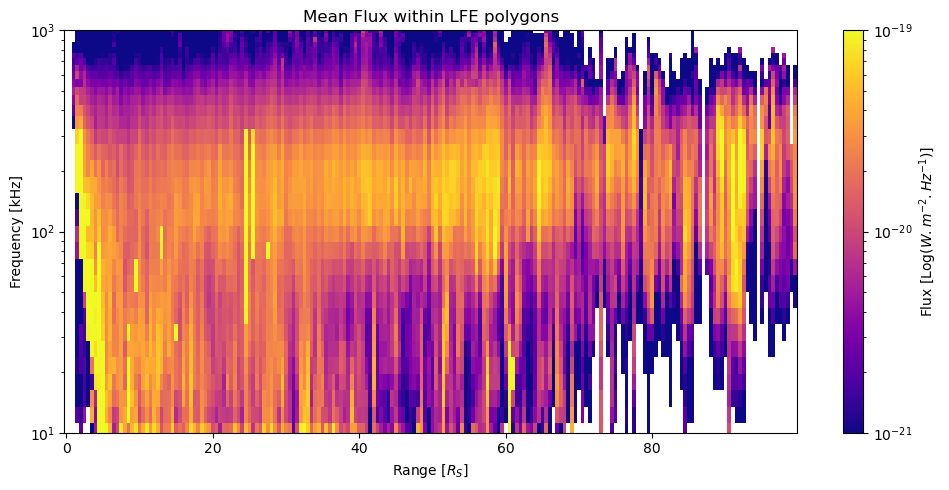

In [19]:
fig = plt.figure(figsize=(10,5), dpi=100)
ax = fig.add_subplot()

#norm = mp_colors.LogNorm()
norm = mp_colors.LogNorm(vmin=1e-21, vmax=1e-19)
cbar = ax.pcolormesh(bins[:-1], ds["frequency"], mean_flux.T, norm=norm, cmap='plasma')

fig.colorbar(cbar, label=r'Flux [Log($W.m^{-2}.Hz^{-1}$)]')

#ax.set_xticks(bins[:-1:10])
#ax.set_xticks(bins[:-1], minor=True) # Check minute ticks to macth bins
#ax.set_xticks(bins[:-1])

#ax.xaxis.set_major_formatter('{x:.0f}:00')

ax.set_yscale('log')
ax.set_ylim([1e1,1e3])
ax.set_xlabel('Range [$R_S$]')
ax.set_ylabel('Frequency [kHz]')
ax.set_title('Mean Flux within LFE polygons')

plt.tight_layout()    
plt.savefig("Mean_LFE_spectrogram_Range.pdf",format="pdf")
plt.show()    

think about data distribution

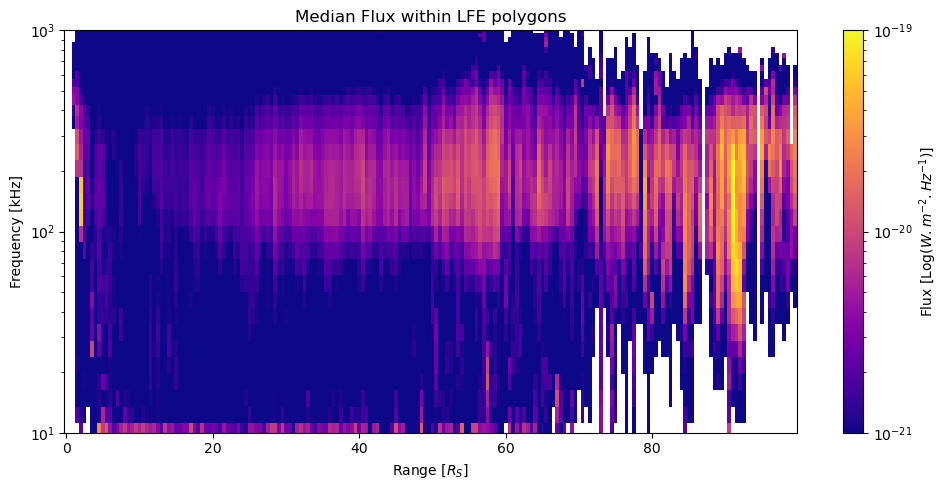

In [21]:
fig = plt.figure(figsize=(10,5), dpi=100)
ax = fig.add_subplot()

#norm = mp_colors.LogNorm()
norm = mp_colors.LogNorm(vmin=1e-21, vmax=1e-19)
cbar = ax.pcolormesh(bins[:-1], ds["frequency"], median_flux.T, norm=norm, cmap='plasma')

fig.colorbar(cbar, label=r'Flux [Log($W.m^{-2}.Hz^{-1}$)]')

#ax.set_xticks(bins[:-1:10])
#ax.set_xticks(bins[:-1], minor=True) # Check minute ticks to macth bins
#ax.set_xticks(bins[:-1])

#ax.xaxis.set_major_formatter('{x:.0f}:00')

ax.set_yscale('log')
ax.set_ylim([1e1,1e3])
ax.set_xlabel('Range [$R_S$]')
ax.set_ylabel('Frequency [kHz]')
ax.set_title('Median Flux within LFE polygons')

plt.tight_layout()    
plt.savefig("Median_LFE_spectrogram_Range.pdf",format="pdf")
plt.show()    

